In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Generate dummy data for demonstration
np.random.seed(42)

# Number of samples
n_samples = 1000

# Features
temperature = np.random.uniform(0, 35, n_samples) # Celsius
humidity = np.random.uniform(30, 90, n_samples)   # Percentage
time_of_day_hour = np.random.randint(0, 24, n_samples) # Hour of the day
is_weekend = np.random.randint(0, 2, n_samples) # 0 for weekday, 1 for weekend

# Simulate energy consumption (target variable)
# Energy = f(temperature, humidity, time_of_day) + noise
energy_consumption = (50 + temperature * 2 + humidity * 0.5 +
                      np.sin(time_of_day_hour / 24 * 2 * np.pi) * 30 +
                      is_weekend * 10 + np.random.normal(0, 5, n_samples))

data = pd.DataFrame({
    'temperature': temperature,
    'humidity': humidity,
    'time_of_day_hour': time_of_day_hour,
    'is_weekend': is_weekend,
    'energy_consumption': energy_consumption
})

print("Generated Dummy Data Head:")
display(data.head())

Generated Dummy Data Head:


,temperature,humidity,time_of_day_hour,is_weekend,energy_consumption
0,13.108904,41.107976,6,1,139.099716
1,33.275001,62.514057,2,0,169.521401
2,25.619788,82.376750,22,1,139.411101
3,20.953047,73.933493,13,1,124.538962
4,5.460652,78.393669,23,1,98.344632


In [3]:
# Define features (X) and target (y)
X = data[['temperature', 'humidity', 'time_of_day_hour', 'is_weekend']]
y = data['energy_consumption']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (800, 4)
Testing data shape: (200, 4)


Linear Regression - Mean Squared Error: 187.38
Linear Regression - R-squared: 0.79


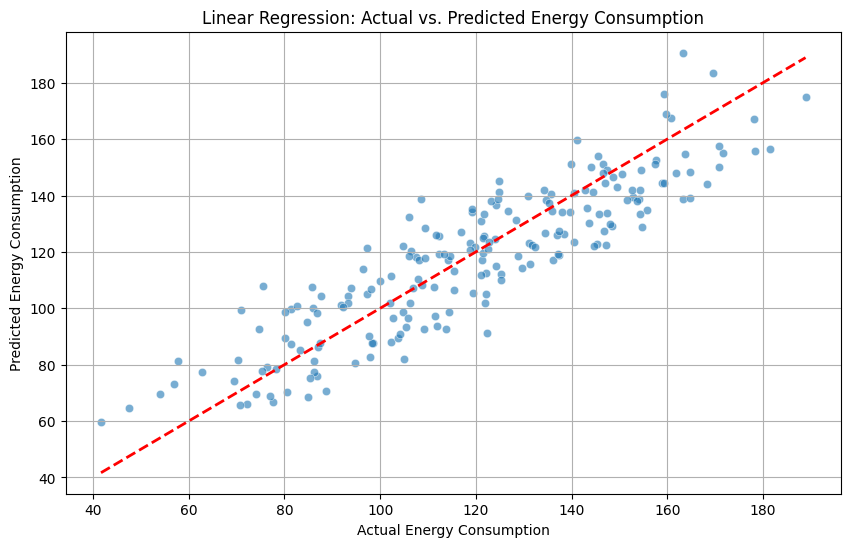

In [4]:
# Initialize and train the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = linear_model.predict(X_test)

# Evaluate the model
mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print(f"Linear Regression - Mean Squared Error: {mse_lr:.2f}")
print(f"Linear Regression - R-squared: {r2_lr:.2f}")

# Plotting predictions vs actual for Linear Regression
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # identity line
plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("Linear Regression: Actual vs. Predicted Energy Consumption")
plt.grid(True)
plt.show()

Random Forest Regressor - Mean Squared Error: 60.82
Random Forest Regressor - R-squared: 0.93


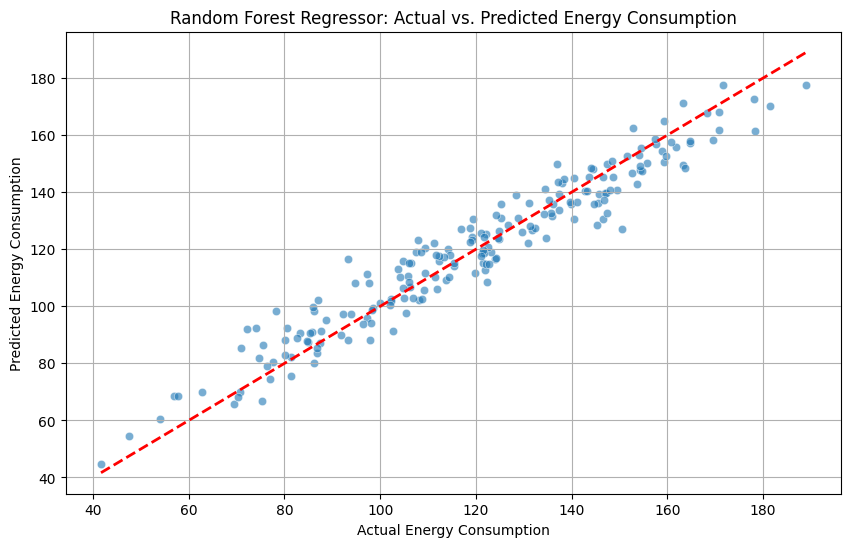

In [6]:
# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Regressor - Mean Squared Error: {mse_rf:.2f}")
print(f"Random Forest Regressor - R-squared: {r2_rf:.2f}")

# Plotting predictions vs actual for Random Forest
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # identity line
plt.xlabel("Actual Energy Consumption")
plt.ylabel("Predicted Energy Consumption")
plt.title("Random Forest Regressor: Actual vs. Predicted Energy Consumption")
plt.grid(True)
plt.show()